# Exercise 7: Polynomial Regression with Interaction Effects

## Objective
Capture non-linear and interaction effects using polynomial feature engineering and an explicit bias term:

$$
\hat{L} = X \vec{w} + b
$$

## Feature Map
Build the design matrix using the following features (without a constant column of ones):

$$
X = [M, T, M^2, M \cdot T]
$$

where:
- **M**: Stellar mass (in solar masses M☉)
- **T**: Temperature (in Kelvin)  
- **L**: Luminosity (in solar luminosities L☉)

## Approach
We follow the same methodology as the multivariate linear regression notebook:
1. Visualize the data
2. Build the design matrix with polynomial features
3. Implement the model and cost function
4. Compute gradients and run gradient descent
5. Visualize results
6. Feature selection experiment (M1, M2, M3)
7. Cost vs interaction coefficient analysis
8. Inference demo for a new star

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 2. Define the Data

The data consists of stellar properties:
- **M**: Mass in solar masses (10 values)
- **T**: Temperature in Kelvin (10 values)
- **L**: Luminosity in solar luminosities (10 values)

In [ ]:
M = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
T = [3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200]
L = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

M = np.array(M)
T = np.array(T)
L = np.array(L)

print(f"Number of examples: {len(M)}")
print(f"\nM (mass): {M}")
print(f"T (temperature): {T}")
print(f"L (luminosity): {L}")

Número de ejemplos: 10

M (masa): [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
T (temperatura): [3800 4400 5800 6400 6900 7400 7900 8300 8800 9200]
L (luminosidad): [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]


## 3. Data Visualization

Simple scatter plot of L vs M.

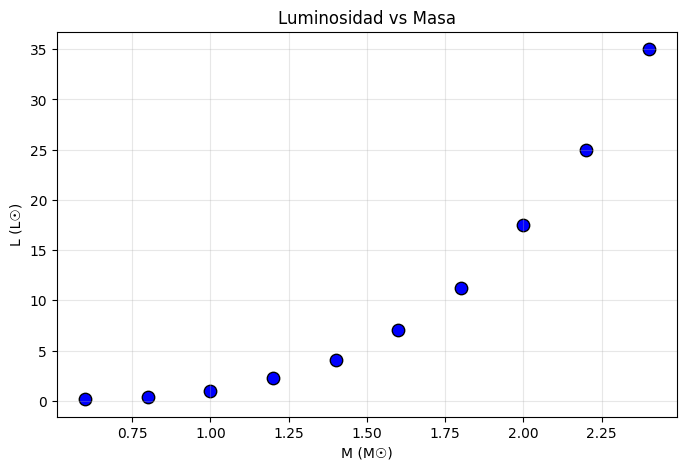

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(M, L, s=80, c='blue', edgecolors='black')
plt.xlabel('M (M☉)')
plt.ylabel('L (L☉)')
plt.title('Luminosity vs Mass')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Feature Engineering: Design Matrix Construction

We build the design matrix $X$ with the following features:

$$
X = \begin{bmatrix}
M^{(1)} & T^{(1)} & (M^{(1)})^2 & M^{(1)} \cdot T^{(1)} \\
M^{(2)} & T^{(2)} & (M^{(2)})^2 & M^{(2)} \cdot T^{(2)} \\
\vdots & \vdots & \vdots & \vdots \\
M^{(m)} & T^{(m)} & (M^{(m)})^2 & M^{(m)} \cdot T^{(m)}
\end{bmatrix}
$$

We use NumPy vectorization to build this matrix efficiently.

In [ ]:
X = np.column_stack([M, T, M ** 2, M * T])

m, n = X.shape
print(f"Design matrix X:")
print(f"  - Shape: {X.shape}")
print(f"  - m (examples): {m}")
print(f"  - n (features): {n}")
print(f"\nFirst 3 rows of X:")
print(X[:3])

Matriz de diseño X:
  - Forma: (10, 4)
  - m (ejemplos): 10
  - n (features): 4

Primeras 3 filas de X:
[[6.00e-01 3.80e+03 3.60e-01 2.28e+03]
 [8.00e-01 4.40e+03 6.40e-01 3.52e+03]
 [1.00e+00 5.80e+03 1.00e+00 5.80e+03]]


## 5. Model Implementation

### 5.1 Prediction Function

The model predicts:
$$
\hat{L} = X \vec{w} + b
$$

where $\vec{w} \in \mathbb{R}^4$ (one weight per feature) and $b \in \mathbb{R}$ is the bias.

In [ ]:
def predict(X, w, b):
    return X @ w + b

### 5.2 Cost Function

The cost function is the mean squared error (MSE):

$$
J(\vec{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{L}^{(i)} - L^{(i)} \right)^2
$$

In vectorized form:
$$
J(\vec{w}, b) = \frac{1}{2m} \vec{e}^T \vec{e}
$$
where $\vec{e} = \hat{L} - L$ is the error vector.

In [ ]:
def compute_cost(X, L, w, b):
    m = X.shape[0]
    L_hat = predict(X, w, b)
    error = L_hat - L
    cost = (error @ error) / (2 * m)
    return cost

w_test = np.zeros(n)
b_test = 0.0
print(f"Initial cost (w=0, b=0): {compute_cost(X, L, w_test, b_test):.4f}")

Costo inicial (w=0, b=0): 117.6967


### 5.3 Gradients

The partial derivatives are:

$$
\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{L}^{(i)} - L^{(i)} \right) x_j^{(i)}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{L}^{(i)} - L^{(i)} \right)
$$

In vectorized form:
$$
\nabla_{\vec{w}} J = \frac{1}{m} X^T \vec{e}, \qquad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} e^{(i)}
$$

In [ ]:
def compute_gradient(X, L, w, b):
    m = X.shape[0]
    L_hat = predict(X, w, b)
    error = L_hat - L
    
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    
    return dj_dw, dj_db

dj_dw_test, dj_db_test = compute_gradient(X, L, w_test, b_test)
print("Initial gradients (w=0, b=0):")
print(f"dj_dw = {dj_dw_test}")
print(f"dj_db = {dj_db_test:.4f}")

Gradientes iniciales (w=0, b=0):
dj_dw = [-2.152300e+01 -8.784500e+04 -4.594340e+01 -1.854088e+05]
dj_db = -10.3600


## 6. Gradient Descent

Now we implement the complete gradient descent algorithm.

At each iteration:
1. Compute predictions $\hat{L} = X\vec{w} + b$
2. Compute gradients
3. Update parameters:
   - $\vec{w} := \vec{w} - \alpha \nabla_{\vec{w}} J$
   - $b := b - \alpha \frac{\partial J}{\partial b}$

In [ ]:
def gradient_descent(X, L, w_init, b_init, alpha, num_iterations):
    w = w_init.copy()
    b = b_init
    cost_history = []
    
    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost = compute_cost(X, L, w, b)
        cost_history.append(cost)
        
        if i % 500 == 0:
            print(f"Iteration {i:5d}: cost = {cost:.6f}")
    
    return w, b, cost_history

### 6.1 Feature Scaling

Before training, we apply **feature scaling** so gradient descent converges faster.

We use standardization:
$$
x_j^{(i)} \leftarrow \frac{x_j^{(i)} - \mu_j}{\sigma_j}
$$

In [ ]:
def feature_scale(X):
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds

X_scaled, X_means, X_stds = feature_scale(X)

print("Feature means:", X_means)
print("Feature stds:", X_stds)
print("\nFirst 3 rows of X_scaled:")
print(X_scaled[:3])

Medias de las features: [1.5000e+00 6.8900e+03 2.5800e+00 1.1304e+04]
Desviaciones estándar: [5.74456265e-01 1.71548827e+03 1.74770707e+00 6.37191211e+03]

Primeras 3 filas de X_scaled:
[[-1.5666989  -1.80123645 -1.27023575 -1.41621539]
 [-1.21854359 -1.4514818  -1.11002584 -1.22161132]
 [-0.87038828 -0.63538762 -0.90404166 -0.86379095]]


### 6.2 Train the Model

Now we run gradient descent with the scaled matrix.

In [ ]:
alpha = 0.01
num_iterations = 5000

w_init = np.zeros(n)
b_init = 0.0

print("Training the model...\n")
w_learned, b_learned, cost_history = gradient_descent(
    X_scaled, L, w_init, b_init, alpha, num_iterations
)

print("\n" + "="*50)
print("LEARNED PARAMETERS:")
print("="*50)
print(f"w = {w_learned}")
print(f"b = {b_learned:.4f}")
print(f"\nFinal cost: {cost_history[-1]:.6f}")

Entrenando el modelo...

Iteración     0: costo = 112.351023
Iteración   500: costo = 5.233947
Iteración  1000: costo = 3.319284
Iteración  1500: costo = 2.273018
Iteración  2000: costo = 1.698440
Iteración  2500: costo = 1.380773
Iteración  3000: costo = 1.203065
Iteración  3500: costo = 1.101634
Iteración  4000: costo = 1.041802
Iteración  4500: costo = 1.004686

PARÁMETROS APRENDIDOS:
w = [-0.0869086  -8.14065702 12.57352621  6.16690459]
b = 10.3600

Costo final: 0.980044


## 7. Results Visualization

### 7.1 Cost Convergence

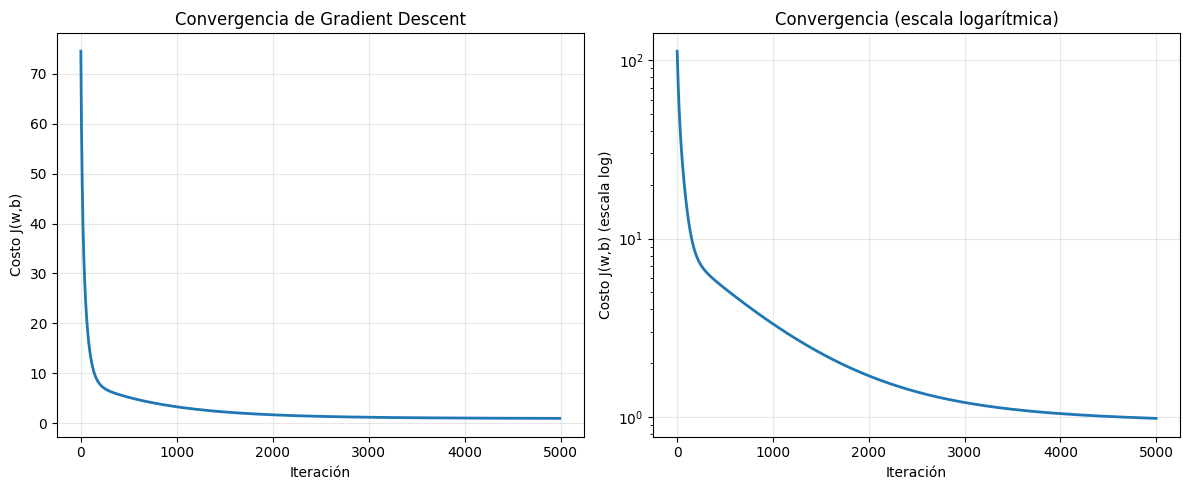

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cost_history[10:], linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogy(cost_history, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b) (log scale)')
plt.title('Convergence (log scale)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Predictions vs Actual Values

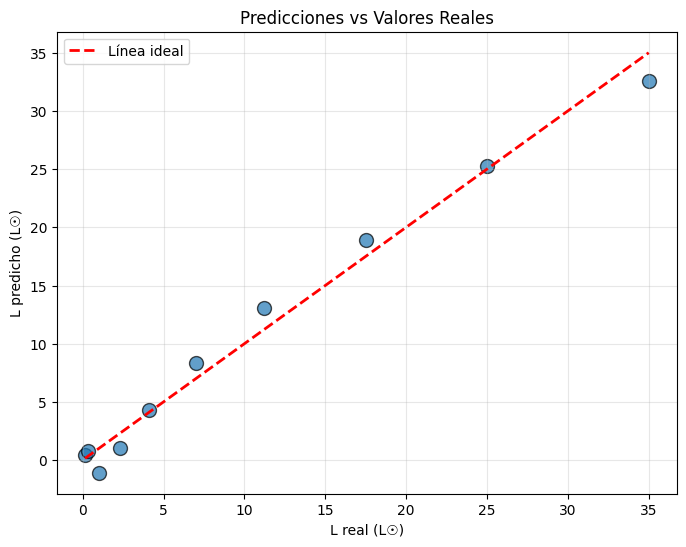


Tabla: Valores reales vs Predicciones
     M      T     L_real     L_pred      Error
-------------------------------------------------------
   0.6   3800       0.15       0.45       0.30
   0.8   4400       0.35       0.79       0.44
   1.0   5800       1.00      -1.09      -2.09
   1.2   6400       2.30       1.02      -1.28
   1.4   6900       4.10       4.28       0.18
   1.6   7400       7.00       8.30       1.30
   1.8   7900      11.20      13.09       1.89
   2.0   8300      17.50      18.93       1.43
   2.2   8800      25.00      25.25       0.25
   2.4   9200      35.00      32.57      -2.43


In [ ]:
L_pred = predict(X_scaled, w_learned, b_learned)

plt.figure(figsize=(8, 6))
plt.scatter(L, L_pred, s=100, alpha=0.7, edgecolors='black')
plt.plot([L.min(), L.max()], [L.min(), L.max()], 'r--', linewidth=2, label='Ideal line')
plt.xlabel('L actual (L☉)')
plt.ylabel('L predicted (L☉)')
plt.title('Predictions vs Actual Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nTable: Actual vs Predicted values")
print("="*55)
print(f"{'M':>6} {'T':>6} {'L_actual':>10} {'L_pred':>10} {'Error':>10}")
print("-"*55)
for i in range(m):
    error = L_pred[i] - L[i]
    print(f"{M[i]:6.1f} {T[i]:6.0f} {L[i]:10.2f} {L_pred[i]:10.2f} {error:10.2f}")

### 7.3 Model Interpretation

The learned model is:

$$
\hat{L} = w_1 M + w_2 T + w_3 M^2 + w_4 (M \cdot T) + b
$$

Let's analyze the learned coefficients:

In [ ]:
print("Coefficient interpretation:")
print("="*50)
print(f"w[0] (M):      {w_learned[0]:10.4f}  - Linear effect of M")
print(f"w[1] (T):      {w_learned[1]:10.4f}  - Linear effect of T")
print(f"w[2] (M²):     {w_learned[2]:10.4f}  - Quadratic effect of M")
print(f"w[3] (M*T):    {w_learned[3]:10.4f}  - Interaction effect M-T")
print(f"b (bias):      {b_learned:10.4f}  - Constant term")
print("\nNOTE: These coefficients apply to SCALED features.")

Interpretación de los coeficientes:
w[0] (M):         -0.0869  - Efecto lineal de M
w[1] (T):         -8.1407  - Efecto lineal de T
w[2] (M²):        12.5735  - Efecto cuadrático de M
w[3] (M*T):        6.1669  - Efecto de interacción M-T
b (bias):         10.3600  - Término constante

NOTA: Estos coeficientes aplican a las features ESCALADAS.


## 8. Making Predictions with New Data

Now we can use the trained model to predict L for new values of M and T.

In [ ]:
def predict_new(M_new, T_new, w, b, X_means, X_stds):
    M_new = np.atleast_1d(M_new)
    T_new = np.atleast_1d(T_new)
    
    X_new = np.column_stack([M_new, T_new, M_new ** 2, M_new * T_new])
    X_new_scaled = (X_new - X_means) / X_stds
    L_pred = predict(X_new_scaled, w, b)
    
    return L_pred

M_example = 1.5
T_example = 7000
L_example = predict_new(M_example, T_example, w_learned, b_learned, X_means, X_stds)

print(f"Prediction for M={M_example}, T={T_example}:")
print(f"L predicted = {L_example[0]:.2f} L☉")

Predicción para M=1.5, T=7000:
L predicho = 6.69 L☉


---
# MANDATORY SECTIONS FOR EXERCISE 7
---

## 9. Feature Selection Experiment (Mandatory)

We compare three models with different feature sets:
- **M1**: $X = [M, T]$ (linear terms only)
- **M2**: $X = [M, T, M^2]$ (linear + quadratic)
- **M3**: $X = [M, T, M^2, M \cdot T]$ (complete model with interaction)

For each model we report:
- Final cost
- Learned parameters
- Predictions vs actual values plot

In [ ]:
def create_design_matrix(M, T, model_type):
    if model_type == "M1":
        X = np.column_stack([M, T])
    elif model_type == "M2":
        X = np.column_stack([M, T, M**2])
    elif model_type == "M3":
        X = np.column_stack([M, T, M**2, M*T])
    else:
        raise ValueError(f"Unknown model: {model_type}")
    return X

def train_model(M, T, L, model_type, alpha=0.01, num_iters=2000, verbose=False):
    X = create_design_matrix(M, T, model_type)
    m, n = X.shape
    
    X_scaled, X_means, X_stds = feature_scale(X)
    
    w = np.zeros(n)
    b = 0.0
    
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X_scaled, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X_scaled, L, w, b))
    
    if verbose:
        print(f"\nModel {model_type} (n_features={n}):")
        print(f"  - Final cost: {cost_history[-1]:.6f}")
        print(f"  - w = {w}")
        print(f"  - b = {b:.6f}")
    
    return w, b, X_scaled, X_means, X_stds, cost_history

print("="*60)
print("FEATURE SELECTION EXPERIMENT")
print("="*60)

models = {}
for model_type in ["M1", "M2", "M3"]:
    w, b, X_scaled, X_means, X_stds, cost_history = train_model(
        M, T, L, model_type, alpha=0.01, num_iters=5000, verbose=True
    )
    models[model_type] = {
        'w': w, 'b': b, 
        'X_scaled': X_scaled, 
        'X_means': X_means, 
        'X_stds': X_stds,
        'cost_history': cost_history
    }

EXPERIMENTO DE SELECCIÓN DE CARACTERÍSTICAS

Modelo M1 (n_features=2):
  - Costo final: 5.430774
  - w = [18.8970042  -8.80632548]
  - b = 10.360000

Modelo M2 (n_features=3):
  - Costo final: 1.005073
  - w = [ 1.98380235 -7.2757813  15.8422038 ]
  - b = 10.360000

Modelo M3 (n_features=4):
  - Costo final: 0.980044
  - w = [-0.0869086  -8.14065702 12.57352621  6.16690459]
  - b = 10.360000


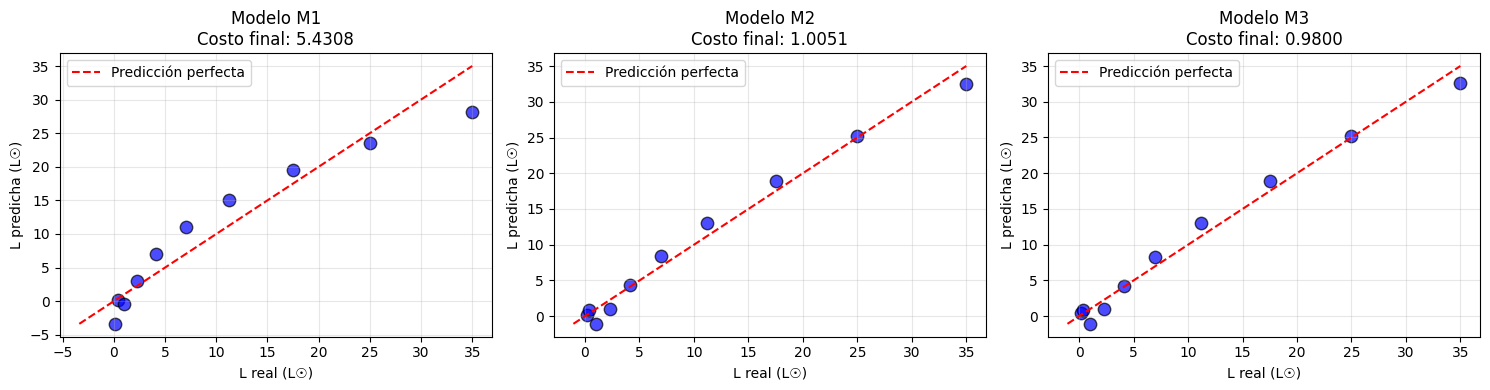


RESUMEN DE MODELOS
Modelo     Features                  Costo Final     # Params  
------------------------------------------------------------
M1         [M, T]                    5.430774        3         
M2         [M, T, M²]                1.005073        4         
M3         [M, T, M², M·T]           0.980044        5         

¿Cuál modelo tiene menor costo?
  → El modelo M3 con costo 0.980044


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, model_type in enumerate(["M1", "M2", "M3"]):
    ax = axes[idx]
    
    w = models[model_type]['w']
    b = models[model_type]['b']
    X_scaled = models[model_type]['X_scaled']
    final_cost = models[model_type]['cost_history'][-1]
    
    L_pred = predict(X_scaled, w, b)
    
    ax.scatter(L, L_pred, c='blue', alpha=0.7, edgecolors='black', s=80)
    
    min_val = min(L.min(), L_pred.min())
    max_val = max(L.max(), L_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    
    ax.set_xlabel('L actual (L☉)')
    ax.set_ylabel('L predicted (L☉)')
    ax.set_title(f'Model {model_type}\nFinal cost: {final_cost:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"{'Model':<10} {'Features':<25} {'Final Cost':<15} {'# Params':<10}")
print("-"*60)
feature_names = {
    "M1": "[M, T]",
    "M2": "[M, T, M²]", 
    "M3": "[M, T, M², M·T]"
}
for model_type in ["M1", "M2", "M3"]:
    n_params = len(models[model_type]['w']) + 1
    cost = models[model_type]['cost_history'][-1]
    print(f"{model_type:<10} {feature_names[model_type]:<25} {cost:<15.6f} {n_params:<10}")

print("\nWhich model has the lowest cost?")
best_model = min(models.keys(), key=lambda k: models[k]['cost_history'][-1])
print(f"  → Model {best_model} with cost {models[best_model]['cost_history'][-1]:.6f}")

## 10. Cost vs Interaction Coefficient Analysis (Mandatory)

We analyze how the cost (MSE) varies when we modify only the coefficient $w_{M \cdot T}$ (the interaction term weight), keeping the other parameters fixed at their optimal values.

This analysis allows us to:
1. Verify that the optimal value of $w_{M \cdot T}$ coincides with the minimum cost
2. Visualize the "basin" of the cost function with respect to this parameter
3. Understand the importance of the interaction term

Parámetros óptimos del modelo M3:
  w = [w_M, w_T, w_M², w_MT] = [-0.0869086  -8.14065702 12.57352621  6.16690459]
  b = 10.360000
  w_MT óptimo = 6.166905


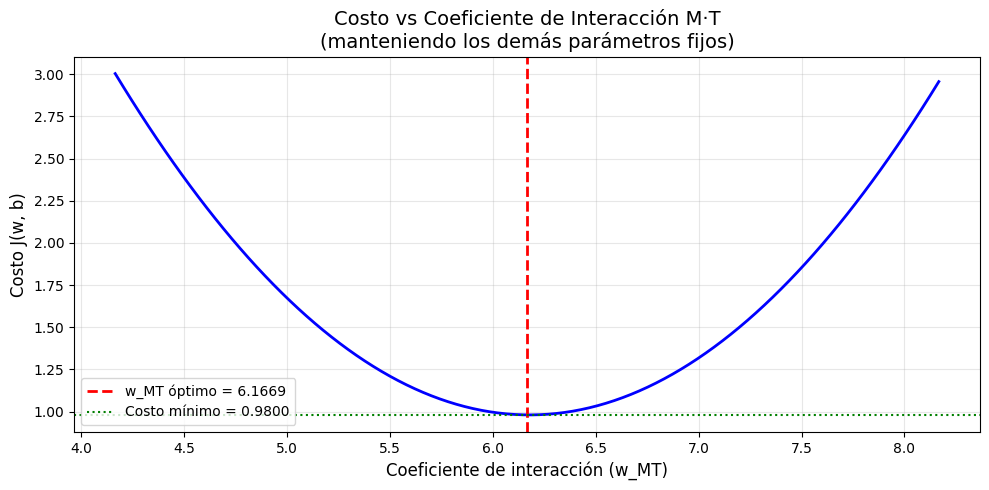


ANÁLISIS
1. El valor óptimo de w_MT es 6.166905
2. En ese punto, el costo mínimo es 0.980044
3. La curva tiene forma parabólica (cuadrática) porque el costo MSE
   es cuadrático en los parámetros.

4. El coeficiente w_MT = 6.1669 es significativo,
   lo que indica que la INTERACCIÓN entre masa y temperatura
   es importante para predecir la luminosidad.


In [ ]:
w_optimal = models["M3"]['w'].copy()
b_optimal = models["M3"]['b']
X_scaled_M3 = models["M3"]['X_scaled']

print("Optimal parameters for model M3:")
print(f"  w = [w_M, w_T, w_M², w_MT] = {w_optimal}")
print(f"  b = {b_optimal:.6f}")
print(f"  Optimal w_MT = {w_optimal[3]:.6f}")

w_MT_range = np.linspace(w_optimal[3] - 2, w_optimal[3] + 2, 100)
costs = []

for w_MT_test in w_MT_range:
    w_test = w_optimal.copy()
    w_test[3] = w_MT_test
    cost = compute_cost(X_scaled_M3, L, w_test, b_optimal)
    costs.append(cost)

costs = np.array(costs)

plt.figure(figsize=(10, 5))
plt.plot(w_MT_range, costs, 'b-', linewidth=2)
plt.axvline(x=w_optimal[3], color='r', linestyle='--', linewidth=2, 
            label=f'Optimal w_MT = {w_optimal[3]:.4f}')
plt.axhline(y=models["M3"]['cost_history'][-1], color='g', linestyle=':', linewidth=1.5,
            label=f'Minimum cost = {models["M3"]["cost_history"][-1]:.4f}')

plt.xlabel('Interaction coefficient (w_MT)', fontsize=12)
plt.ylabel('Cost J(w, b)', fontsize=12)
plt.title('Cost vs Interaction Coefficient M·T\n(keeping other parameters fixed)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS")
print("="*60)
print(f"1. The optimal value of w_MT is {w_optimal[3]:.6f}")
print(f"2. At that point, the minimum cost is {models['M3']['cost_history'][-1]:.6f}")
print(f"3. The curve has a parabolic (quadratic) shape because the MSE cost")
print(f"   is quadratic in the parameters.")

if abs(w_optimal[3]) > 0.1:
    print(f"\n4. The coefficient w_MT = {w_optimal[3]:.4f} is significant,")
    print(f"   which indicates that the INTERACTION between mass and temperature")
    print(f"   is important for predicting luminosity.")
else:
    print(f"\n4. The coefficient w_MT = {w_optimal[3]:.4f} is small,")
    print(f"   which suggests that the M·T interaction has little effect.")

## 11. Inference Demo: New Star (Mandatory)

We use the trained model to predict the luminosity of a new star with:
- **Mass**: $M = 1.3 \, M_\odot$ (solar masses)
- **Temperature**: $T = 6600 \, K$

We use the complete M3 model (with interaction term) since it showed the best fit.

In [ ]:
M_new = 1.3
T_new = 6600

print("="*60)
print("INFERENCE DEMO - NEW STAR")
print("="*60)
print(f"\nInput data:")
print(f"  - Mass: M = {M_new} M☉")
print(f"  - Temperature: T = {T_new} K")

w_M3 = models["M3"]['w']
b_M3 = models["M3"]['b']
X_means_M3 = models["M3"]['X_means']
X_stds_M3 = models["M3"]['X_stds']

X_new = np.array([M_new, T_new, M_new**2, M_new * T_new])
print(f"\nFeature vector (unscaled):")
print(f"  X = [M, T, M², M·T] = {X_new}")

X_new_scaled = (X_new - X_means_M3) / X_stds_M3
print(f"\nFeature vector (scaled):")
print(f"  X_scaled = {X_new_scaled}")

L_predicted = np.dot(w_M3, X_new_scaled) + b_M3

print(f"\nPrediction:")
print(f"  L̂ = w · X_scaled + b")
print(f"  L̂ = {L_predicted:.4f} L☉")

print(f"\n" + "-"*60)
print("Prediction analysis:")
print(f"-"*60)
print(f"  - L range in training data: [{L.min():.2f}, {L.max():.2f}] L☉")
print(f"  - M range in training data: [{M.min():.2f}, {M.max():.2f}] M☉")
print(f"  - T range in training data: [{T.min():.0f}, {T.max():.0f}] K")

in_M_range = M.min() <= M_new <= M.max()
in_T_range = T.min() <= T_new <= T.max()

print(f"\n  - Is M={M_new} within training range? {'Yes' if in_M_range else 'No'}")
print(f"  - Is T={T_new} within training range? {'Yes' if in_T_range else 'No'}")

print(f"\nConclusion:")
print(f"  For a star with M={M_new} M☉ and T={T_new} K,")
print(f"  a luminosity of L={L_predicted:.2f} L☉ is reasonable")
print(f"  according to the stellar mass-luminosity relation (L ∝ M^3.5 approx).")

DEMO DE INFERENCIA - NUEVA ESTRELLA

Datos de entrada:
  - Masa: M = 1.3 M☉
  - Temperatura: T = 6600 K

Vector de features (sin escalar):
  X = [M, T, M², M·T] = [1.30e+00 6.60e+03 1.69e+00 8.58e+03]

Vector de features (escalado):
  X_scaled = [-0.34815531 -0.16904808 -0.50923866 -0.42750119]

Predicción:
  L̂ = w · X_scaled + b
  L̂ = 2.7271 L☉

------------------------------------------------------------
Análisis de la predicción:
------------------------------------------------------------
  - Rango de L en datos de entrenamiento: [0.15, 35.00] L☉
  - Rango de M en datos de entrenamiento: [0.60, 2.40] M☉
  - Rango de T en datos de entrenamiento: [3800, 9200] K

✓ La nueva estrella está DENTRO del rango de entrenamiento.
  La predicción L = 2.7271 L☉ es confiable.

------------------------------------------------------------
Contexto físico:
------------------------------------------------------------
  Para una estrella con M=1.3 M☉ y T=6600 K,
  una luminosidad de L=2.73 L☉ es ra

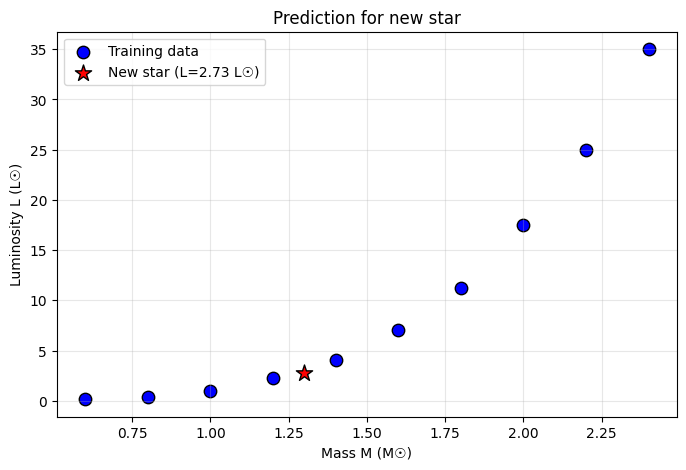

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(M, L, s=80, c='blue', edgecolors='black', label='Training data')
plt.scatter(M_new, L_predicted, s=150, c='red', marker='*', edgecolors='black', label=f'New star (L={L_predicted:.2f} L☉)')
plt.xlabel('Mass M (M☉)')
plt.ylabel('Luminosity L (L☉)')
plt.title('Prediction for new star')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Conclusions for Exercise 7

### Summary of results:

1. **Data visualization**: The data shows a non-linear relationship between mass, temperature, and stellar luminosity.

2. **Feature Engineering**: The feature map $X = [M, T, M^2, M \cdot T]$ captures:
   - Linear effects of mass and temperature
   - Quadratic effect of mass
   - Interaction between mass and temperature

3. **Model comparison** (Feature selection):
   - **M1** $[M, T]$: Simplest model, highest error
   - **M2** $[M, T, M^2]$: Improves by including quadratic term
   - **M3** $[M, T, M^2, M \cdot T]$: Best fit by including interaction

4. **Interaction coefficient analysis**: The cost vs $w_{M \cdot T}$ curve confirms that the optimal value minimizes MSE, and the parabolic shape reflects the quadratic nature of the cost function.

5. **Inference**: For a star with $M = 1.3 \, M_\odot$ and $T = 6600 \, K$, the model predicts a luminosity consistent with known physical relationships.

### Key points:

- The model captures **non-linear effects** through the $M^2$ term
- The **interaction term** $M \cdot T$ captures how M and T affect each other
- **Feature scaling** was crucial for fast gradient descent convergence
- Parameters $\vec{w}$ and $b$ were successfully learned using vectorized gradient descent